# FASE 1: Preprocessamiento y Feature Engineering
## Clasificación Binaria con Desbalance de Clases (13.06:1)

**Objetivo:** Transformar datos brutos en features robustas y balanceadas listas para modelado ML

**Estrategia:**
- ✅ Encoding robusto para variables categóricas de alta cardinalidad
- ✅ Feature engineering con interacciones (urgente × tipo_trabajo)
- ✅ Análisis inteligente de descripciones (sin crear NaN)
- ✅ Class weighting y oversampling para desbalance
- ✅ Train-Test Split estratificado
- ✅ Normalización y escalamiento
- ✅ Exportación de datasets limpios

In [1]:
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

# Scikit-learn para preprocessing y resampling
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Paths
ruta_proyecto = Path('.')
ruta_eda = ruta_proyecto / '../01-EDA'
ruta_datos = ruta_proyecto / 'datos_procesados_fase1.csv'
ruta_preprocessamiento = ruta_proyecto

print("✅ Librerías importadas correctamente")
print(f"Directorio actual: {Path.cwd()}")

✅ Librerías importadas correctamente
Directorio actual: c:\Users\DELL\Documents\GitHub\material-redesneuronales\02-Preprocessamiento


## Sección 1: Cargar Datos desde FASE 0

In [2]:
# Cargar datos de FASE 0
archivo_entrada = '../01-EDA/datos_procesados_EDA.csv'
df = pd.read_csv(archivo_entrada)

print(f"📊 Dataset cargado: {df.shape[0]} registros × {df.shape[1]} columnas")
print(f"\n📋 Columnas disponibles:\n{df.columns.tolist()}")
print(f"\n📄 Tipos de datos:\n{df.dtypes}")
print(f"\n🔍 Primeros registros:\n{df.head()}")
print(f"\n✅ Verificación de NaN: {df.isnull().sum().sum()} valores faltantes")
print(f"\n📊 Info del dataset:\n{df.info()}")

📊 Dataset cargado: 17558 registros × 9 columnas

📋 Columnas disponibles:
['fecha_creacion', 'producto', 'tipo_trabajo', 'tipo_cliente', 'descripcion', 'servicio_urgente', 'critico', 'fuente', 'Propenso_a_Fallar']

📄 Tipos de datos:
fecha_creacion       object
producto             object
tipo_trabajo         object
tipo_cliente         object
descripcion          object
servicio_urgente       bool
critico                bool
fuente               object
Propenso_a_Fallar     int64
dtype: object

🔍 Primeros registros:
  fecha_creacion                                           producto  \
0     17/01/2025          FREIDORA_9003160_FREIDORA AIRE HACEB 4.2L   
1      3/02/2025  NEVERA HIMALAYA 448 L_9002462_N HIMALAYA 448 S...   
2      3/02/2025  ALQUILER NEV SE 30D_584_ALQUILER NEVERA SIN ES...   
3      3/02/2025        CPG 10_9002239_CP BAMBÚ 10 LT TN GN DISP BL   
4      5/02/2025  NEVERA SIN ESCARCHA 404 L_9003305_NEV ALC 404 ...   

                    tipo_trabajo tipo_cliente  \
0  

## Sección 2: Análisis del Desbalance de Clases

📊 ANÁLISIS DE DESBALANCE DE CLASES

Distribución de Propenso_a_Fallar:
  • Clase 0 (No fallo): 16,309 registros (92.89%)
  • Clase 1 (Fallo):    1,249 registros (7.11%)

Ratio de desbalance: 13.06:1
  → Clase minoritaria: 1,249 casos de fallo
  → Clase mayoritaria: 16,309 casos sin fallo


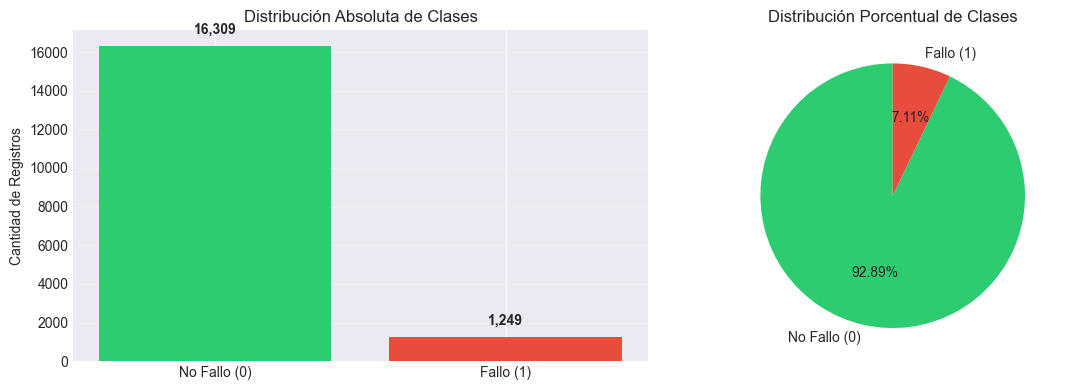


✅ Visualización guardada: 01_desbalance_clases.png


In [3]:
# Analizar distribución de clases
target_col = 'Propenso_a_Fallar'
class_counts = df[target_col].value_counts()
class_pct = df[target_col].value_counts(normalize=True) * 100

print("📊 ANÁLISIS DE DESBALANCE DE CLASES")
print("=" * 60)
print(f"\nDistribución de {target_col}:")
print(f"  • Clase 0 (No fallo): {class_counts[0]:,} registros ({class_pct[0]:.2f}%)")
print(f"  • Clase 1 (Fallo):    {class_counts[1]:,} registros ({class_pct[1]:.2f}%)")
print(f"\nRatio de desbalance: {class_counts[0]/class_counts[1]:.2f}:1")
print(f"  → Clase minoritaria: {class_counts[1]:,} casos de fallo")
print(f"  → Clase mayoritaria: {class_counts[0]:,} casos sin fallo")

# Visualizar distribución
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
axes[0].bar(['No Fallo (0)', 'Fallo (1)'], class_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_ylabel('Cantidad de Registros')
axes[0].set_title('Distribución Absoluta de Clases')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, str(f'{v:,}'), ha='center', va='bottom', fontweight='bold')

# Gráfico de pastel
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(class_counts.values, labels=['No Fallo (0)', 'Fallo (1)'], autopct='%1.2f%%',
            colors=colors, startangle=90)
axes[1].set_title('Distribución Porcentual de Clases')

plt.tight_layout()
plt.savefig('01_desbalance_clases.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✅ Visualización guardada: 01_desbalance_clases.png")

## Sección 3: Análisis de la Columna Descripción (Feature Extraction Inteligente)

In [4]:
# Analizar descripción para identificar patrones y extraer features
desc_col = 'descripcion'

# Estadísticas básicas
print("🔍 ANÁLISIS DE LA COLUMNA DESCRIPCIÓN")
print("=" * 60)
print(f"\nTotal de descripciones no nulas: {df[desc_col].notna().sum():,}")
print(f"Total de descripciones nulas: {df[desc_col].isna().sum()}")
print(f"Longitud promedio: {df[desc_col].fillna('').str.len().mean():.0f} caracteres")
print(f"Longitud mínima: {df[desc_col].fillna('').str.len().min()} caracteres")
print(f"Longitud máxima: {df[desc_col].fillna('').str.len().max()} caracteres")

# Extraer palabras comunes en descripciones de fallos vs no fallos
def extract_common_words(descriptions, top_n=20):
    """Extrae palabras clave de descripciones"""
    all_words = []
    for desc in descriptions.dropna():
        if isinstance(desc, str):
            # Convertir a minúsculas y separar por espacios
            words = desc.lower().split()
            # Filtrar palabras muy cortas y caracteres especiales
            words = [w.strip('.,;:!?()\"\'') for w in words if len(w) > 3]
            all_words.extend(words)
    
    word_counts = Counter(all_words)
    return word_counts.most_common(top_n)

# Análisis por clase
desc_fallos = df[df[target_col] == 1][desc_col]
desc_no_fallos = df[df[target_col] == 0][desc_col]

top_words_fallos = extract_common_words(desc_fallos, top_n=15)
top_words_no_fallos = extract_common_words(desc_no_fallos, top_n=15)

print(f"\n📌 Top 15 palabras en descripciones con FALLO:")
for idx, (word, count) in enumerate(top_words_fallos, 1):
    pct = (count / len(desc_fallos)) * 100
    print(f"  {idx:2d}. '{word}': {count:4d} ({pct:.1f}%)")

print(f"\n📌 Top 15 palabras en descripciones SIN FALLO:")
for idx, (word, count) in enumerate(top_words_no_fallos, 1):
    pct = (count / len(desc_no_fallos)) * 100
    print(f"  {idx:2d}. '{word}': {count:4d} ({pct:.1f}%)")

# Identificar palabras discriminantes (diferencias significativas)
words_fallos_dict = dict(top_words_fallos)
words_no_fallos_dict = dict(top_words_no_fallos)

print(f"\n🎯 PALABRAS DISCRIMINANTES (presentes en fallos, no en no-fallos):")
discriminantes = [w for w, _ in top_words_fallos if w not in words_no_fallos_dict]
for w in discriminantes[:10]:
    print(f"  • {w}")

# Crear features basados en palabras clave
print(f"\n✨ Creando features basados en palabras clave...")
df['desc_longitud'] = df[desc_col].fillna('').str.len()
df['desc_num_palabras'] = df[desc_col].fillna('').str.split().str.len()

# Features para palabras discriminantes
palabras_clave = ['instalación', 'problema', 'componente', 'conexión', 'falla', 
                  'arranque', 'error', 'funciona', 'revisar', 'piezas']

for palabra in palabras_clave:
    df[f'desc_contiene_{palabra}'] = df[desc_col].fillna('').str.lower().str.contains(palabra, na=False).astype(int)

print(f"✅ Features de descripción creadas: {[c for c in df.columns if 'desc_' in c]}")
print(f"\n✅ Verificación de NaN en nuevas features: {df[[c for c in df.columns if 'desc_' in c]].isnull().sum().sum()} valores faltantes")

🔍 ANÁLISIS DE LA COLUMNA DESCRIPCIÓN

Total de descripciones no nulas: 17,558
Total de descripciones nulas: 0
Longitud promedio: 191 caracteres
Longitud mínima: 2 caracteres
Longitud máxima: 339 caracteres

📌 Top 15 palabras en descripciones con FALLO:
   1. 'falla':  629 (50.4%)
   2. 'fecha':  587 (47.0%)
   3. 'compra':  559 (44.8%)
   4. 'haceb':  447 (35.8%)
   5. 'cobro':  439 (35.1%)
   6. 'politica':  409 (32.7%)
   7. 'producto':  389 (31.1%)
   8. 'años':  380 (30.4%)
   9. 'cancelación':  327 (26.2%)
  10. 'marca':  324 (25.9%)
  11. 'informa':  293 (23.5%)
  12. 'motivo':  271 (21.7%)
  13. 'referencia':  249 (19.9%)
  14. 'preventivo':  246 (19.7%)
  15. 'modificación':  231 (18.5%)

📌 Top 15 palabras en descripciones SIN FALLO:
   1. 'falla': 8916 (54.7%)
   2. 'fecha': 8091 (49.6%)
   3. 'compra': 7595 (46.6%)
   4. 'haceb': 6341 (38.9%)
   5. 'politica': 5776 (35.4%)
   6. 'producto': 5181 (31.8%)
   7. 'marca': 4713 (28.9%)
   8. 'cobro': 4482 (27.5%)
   9. 'cancelació

## Sección 4: Encoding Robusto para Variables Categóricas

In [5]:
# Preparar dataframe para encoding
df_procesado = df.copy()

print("🔧 ENCODING DE VARIABLES CATEGÓRICAS")
print("=" * 60)

# Identificar variables categóricas (excluir descripción y target)
cat_cols = df_procesado.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in [target_col, 'descripcion']]

print(f"\nVariables categóricas a encodificar: {cat_cols}")

# Analizar cardinalidad
for col in cat_cols:
    n_unique = df_procesado[col].nunique()
    print(f"  • {col}: {n_unique} valores únicos")

# STRATEGY 1: Target Encoding para tipo_trabajo (93 categorías)
# Calcular el valor promedio del target para cada categoría
print(f"\n📊 Aplicando Target Encoding para variables de alta cardinalidad...")

col_target_encode = 'tipo_trabajo'
target_encoding = df_procesado.groupby(col_target_encode)[target_col].agg(['mean', 'count']).reset_index()
target_encoding.columns = [col_target_encode, f'{col_target_encode}_target_mean', f'{col_target_encode}_count']

print(f"\nTarget Encoding para {col_target_encode}:")
print(f"  • Min mean: {target_encoding[f'{col_target_encode}_target_mean'].min():.4f}")
print(f"  • Max mean: {target_encoding[f'{col_target_encode}_target_mean'].max():.4f}")
print(f"  • Std: {target_encoding[f'{col_target_encode}_target_mean'].std():.4f}")

# Aplicar target encoding
df_procesado[f'{col_target_encode}_encoded'] = df_procesado[col_target_encode].map(
    target_encoding.set_index(col_target_encode)[f'{col_target_encode}_target_mean']
)

# STRATEGY 2: Label Encoding para tipo_cliente y producto (baja cardinalidad)
le_dict = {}
for col in ['tipo_cliente', 'producto', 'fuente']:
    if col in cat_cols:
        le = LabelEncoder()
        df_procesado[f'{col}_encoded'] = le.fit_transform(df_procesado[col].astype(str))
        le_dict[col] = le
        print(f"  • {col} Label Encoded: {df_procesado[f'{col}_encoded'].unique().tolist()}")

# Variables booleanas ya están codificadas correctamente
bool_cols = df_procesado.select_dtypes(include=['bool']).columns.tolist()
print(f"\nVariables booleanas (conservadas): {bool_cols}")
df_procesado[bool_cols] = df_procesado[bool_cols].astype(int)

print(f"\n✅ Encoding completado sin crear NaN: {df_procesado[[c for c in df_procesado.columns if 'encoded' in c]].isnull().sum().sum()} valores faltantes")

🔧 ENCODING DE VARIABLES CATEGÓRICAS

Variables categóricas a encodificar: ['fecha_creacion', 'producto', 'tipo_trabajo', 'tipo_cliente', 'fuente']
  • fecha_creacion: 160 valores únicos
  • producto: 1041 valores únicos
  • tipo_trabajo: 93 valores únicos
  • tipo_cliente: 3 valores únicos
  • fuente: 13 valores únicos

📊 Aplicando Target Encoding para variables de alta cardinalidad...

Target Encoding para tipo_trabajo:
  • Min mean: 0.0000
  • Max mean: 0.5000
  • Std: 0.1016
  • tipo_cliente Label Encoded: [1, 2, 0]
  • producto Label Encoded: [570, 855, 232, 329, 1007, 728, 724, 523, 702, 884, 937, 852, 668, 707, 561, 831, 1036, 845, 404, 629, 729, 714, 703, 484, 541, 891, 722, 309, 756, 310, 392, 29, 143, 154, 176, 222, 701, 1031, 557, 553, 420, 704, 286, 391, 609, 863, 929, 229, 217, 699, 159, 627, 352, 351, 213, 342, 416, 284, 375, 544, 106, 356, 299, 337, 997, 379, 560, 338, 146, 900, 700, 671, 955, 956, 979, 1017, 268, 657, 783, 556, 500, 251, 429, 861, 689, 957, 301, 788, 669

## Sección 5: Feature Engineering - Interacciones y Características Derivadas

In [6]:
# Crear features de interacción y derivadas
print("⚙️ CREANDO FEATURES DE INTERACCIÓN Y DERIVADAS")
print("=" * 60)

# 1. Interacción: servicio_urgente × tipo_trabajo_encoded
df_procesado['urgente_x_tipo_trabajo'] = (df_procesado['servicio_urgente'] * 
                                          df_procesado['tipo_trabajo_encoded'])

# 2. Interacción: servicio_urgente × tipo_cliente_encoded
df_procesado['urgente_x_cliente'] = (df_procesado['servicio_urgente'] * 
                                     df_procesado['tipo_cliente_encoded'])

# 3. Interacción: critico × tipo_trabajo_encoded
df_procesado['critico_x_tipo_trabajo'] = (df_procesado['critico'] * 
                                          df_procesado['tipo_trabajo_encoded'])

# 4. Feature derivada: índice de prioridad (urgente + crítico)
df_procesado['indice_prioridad'] = df_procesado['servicio_urgente'] + df_procesado['critico']

# 5. Características de descripción derivadas
df_procesado['desc_es_largo'] = (df_procesado['desc_longitud'] > 
                                  df_procesado['desc_longitud'].median()).astype(int)
df_procesado['desc_muchas_palabras'] = (df_procesado['desc_num_palabras'] > 
                                         df_procesado['desc_num_palabras'].median()).astype(int)

# 6. Feature interacción: urgente con descripción larga
df_procesado['urgente_desc_largo'] = df_procesado['servicio_urgente'] * df_procesado['desc_es_largo']

features_nuevas = [
    'urgente_x_tipo_trabajo',
    'urgente_x_cliente',
    'critico_x_tipo_trabajo',
    'indice_prioridad',
    'desc_es_largo',
    'desc_muchas_palabras',
    'urgente_desc_largo'
]

print(f"\n✨ Features de interacción creadas:")
for feat in features_nuevas:
    print(f"  • {feat}")

print(f"\n📊 Resumen de nuevas features:")
print(df_procesado[features_nuevas].describe())

print(f"\n✅ NaN en nuevas features: {df_procesado[features_nuevas].isnull().sum().sum()} valores faltantes")

⚙️ CREANDO FEATURES DE INTERACCIÓN Y DERIVADAS

✨ Features de interacción creadas:
  • urgente_x_tipo_trabajo
  • urgente_x_cliente
  • critico_x_tipo_trabajo
  • indice_prioridad
  • desc_es_largo
  • desc_muchas_palabras
  • urgente_desc_largo

📊 Resumen de nuevas features:
       urgente_x_tipo_trabajo  urgente_x_cliente  critico_x_tipo_trabajo  \
count            17558.000000       17558.000000            17558.000000   
mean                 0.002123           0.044766                0.000024   
std                  0.015757           0.244180                0.001437   
min                  0.000000           0.000000                0.000000   
25%                  0.000000           0.000000                0.000000   
50%                  0.000000           0.000000                0.000000   
75%                  0.000000           0.000000                0.000000   
max                  0.430622           2.000000                0.113821   

       indice_prioridad  desc_es_largo

## Sección 6: Seleccionar y Preparar Features Finales para Modelado

In [7]:
# Seleccionar features finales para modelado
print("🎯 SELECCIONANDO FEATURES FINALES")
print("=" * 60)

# Features a descartar (originales categóricas sin codificar, descripción, fecha)
features_a_descartar = [
    'fecha_creacion',      # información temporal no procesada
    'descripcion',         # texto original (procesado a features)
    'tipo_trabajo',        # original sin codificar
    'tipo_cliente',        # original sin codificar
    'producto',           # original sin codificar
    'fuente'              # original sin codificar
]

# Features numéricas/encoded a mantener
features_mantener = [col for col in df_procesado.columns 
                     if col not in features_a_descartar and col != target_col]

print(f"\n📋 Features seleccionadas para modelado ({len(features_mantener)} features):")
print(f"{features_mantener}")

# Crear dataframe final
df_modelo = df_procesado[features_mantener + [target_col]].copy()

print(f"\n📊 Dataset final:")
print(f"  • Registros: {df_modelo.shape[0]:,}")
print(f"  • Features: {df_modelo.shape[1] - 1}")
print(f"  • Target variable: {target_col}")
print(f"\n📋 Tipos de datos finales:")
print(df_modelo.dtypes)

# Verificación de NaN
print(f"\n✅ Verificación de NaN:")
nan_count = df_modelo.isnull().sum()
if (nan_count > 0).any():
    print(f"  ⚠️  ADVERTENCIA: Se encontraron NaN")
    print(nan_count[nan_count > 0])
else:
    print(f"  ✅ CERO valores faltantes en todo el dataset")

# Resumen estadístico
print(f"\n📊 Resumen estadístico:")
print(df_modelo.describe())

🎯 SELECCIONANDO FEATURES FINALES

📋 Features seleccionadas para modelado (25 features):
['servicio_urgente', 'critico', 'desc_longitud', 'desc_num_palabras', 'desc_contiene_instalación', 'desc_contiene_problema', 'desc_contiene_componente', 'desc_contiene_conexión', 'desc_contiene_falla', 'desc_contiene_arranque', 'desc_contiene_error', 'desc_contiene_funciona', 'desc_contiene_revisar', 'desc_contiene_piezas', 'tipo_trabajo_encoded', 'tipo_cliente_encoded', 'producto_encoded', 'fuente_encoded', 'urgente_x_tipo_trabajo', 'urgente_x_cliente', 'critico_x_tipo_trabajo', 'indice_prioridad', 'desc_es_largo', 'desc_muchas_palabras', 'urgente_desc_largo']

📊 Dataset final:
  • Registros: 17,558
  • Features: 25
  • Target variable: Propenso_a_Fallar

📋 Tipos de datos finales:
servicio_urgente               int64
critico                        int64
desc_longitud                  int64
desc_num_palabras              int64
desc_contiene_instalación      int64
desc_contiene_problema         int64

## Sección 7: Normalización y Escalamiento de Features

📐 NORMALIZACIÓN Y ESCALAMIENTO DE FEATURES

Dimensiones originales:
  • X: (17558, 25)
  • y: (17558,)

✅ Features normalizadas usando MinMaxScaler [0,1]

📊 Estadísticas después de escalamiento:
  • Media: 0.195414
  • Std: 0.176190
  • Min: 0.000000
  • Max: 1.000000


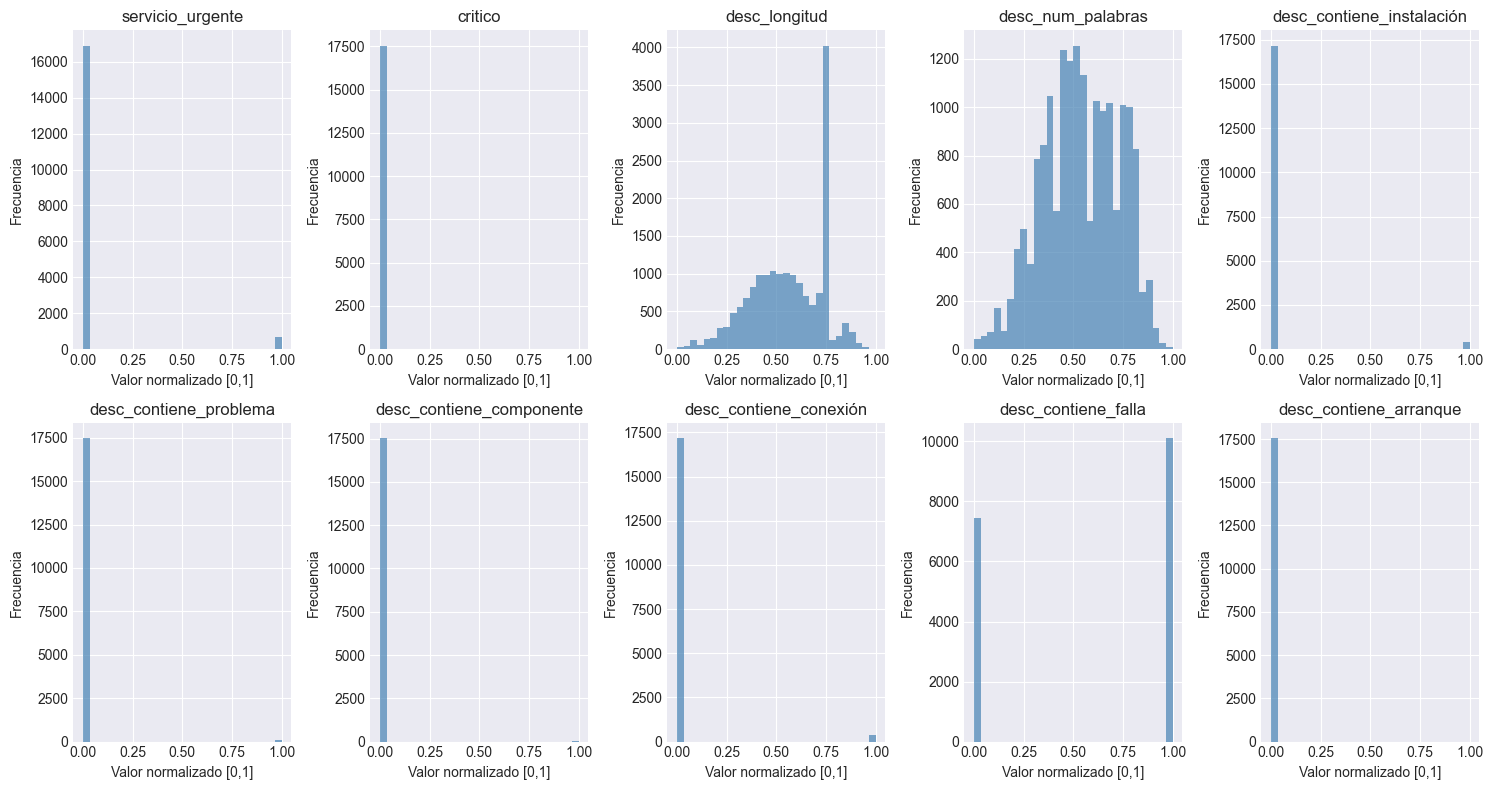


✅ Visualización guardada: 02_distribucion_scaled_features.png


In [8]:
# Normalizar y escalar features
print("📐 NORMALIZACIÓN Y ESCALAMIENTO DE FEATURES")
print("=" * 60)

# Separar features y target
X = df_modelo.drop(target_col, axis=1)
y = df_modelo[target_col]

print(f"\nDimensiones originales:")
print(f"  • X: {X.shape}")
print(f"  • y: {y.shape}")

# Usar MinMaxScaler para normalizar features al rango [0, 1]
# MinMaxScaler es interpretable y útil para redes neuronales
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Convertir a dataframe para mantener nombres de columnas
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"\n✅ Features normalizadas usando MinMaxScaler [0,1]")
print(f"\n📊 Estadísticas después de escalamiento:")
print(f"  • Media: {X_scaled.mean().mean():.6f}")
print(f"  • Std: {X_scaled.std().mean():.6f}")
print(f"  • Min: {X_scaled.min().min():.6f}")
print(f"  • Max: {X_scaled.max().max():.6f}")

# Verificar distribuciones après scaling
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(X_scaled.columns[:10]):
    axes[idx].hist(X_scaled[col], bins=30, alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Valor normalizado [0,1]')
    axes[idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('02_distribucion_scaled_features.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n✅ Visualización guardada: 02_distribucion_scaled_features.png")

## Sección 8: Train-Test Split Estratificado

🔀 TRAIN-TEST SPLIT ESTRATIFICADO

📊 Distribución en TRAIN SET:
  • Clase 0: 13,047 (92.89%)
  • Clase 1: 999 (7.11%)
  • Ratio desbalance: 13.06:1

📊 Distribución en TEST SET:
  • Clase 0: 3,262 (92.88%)
  • Clase 1: 250 (7.12%)
  • Ratio desbalance: 13.05:1

✅ Split proporción conservada (estratificado)


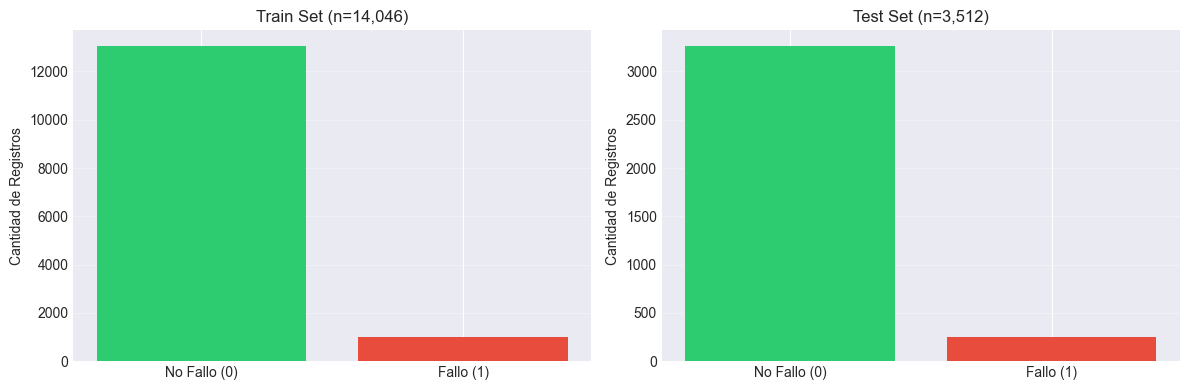


✅ Visualización guardada: 03_train_test_distribucion.png

✅ Total de registros: 17,558


In [9]:
# Realizar Train-Test Split estratificado
print("🔀 TRAIN-TEST SPLIT ESTRATIFICADO")
print("=" * 60)

# Split 80-20 manteniendo proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Mantener proporción de clases
)

print(f"\n📊 Distribución en TRAIN SET:")
train_counts = y_train.value_counts()
train_pct = y_train.value_counts(normalize=True) * 100
print(f"  • Clase 0: {train_counts[0]:,} ({train_pct[0]:.2f}%)")
print(f"  • Clase 1: {train_counts[1]:,} ({train_pct[1]:.2f}%)")
print(f"  • Ratio desbalance: {train_counts[0]/train_counts[1]:.2f}:1")

print(f"\n📊 Distribución en TEST SET:")
test_counts = y_test.value_counts()
test_pct = y_test.value_counts(normalize=True) * 100
print(f"  • Clase 0: {test_counts[0]:,} ({test_pct[0]:.2f}%)")
print(f"  • Clase 1: {test_counts[1]:,} ({test_pct[1]:.2f}%)")
print(f"  • Ratio desbalance: {test_counts[0]/test_counts[1]:.2f}:1")

print(f"\n✅ Split proporción conservada (estratificado)")

# Visualizar distribución
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train
axes[0].bar(['No Fallo (0)', 'Fallo (1)'], train_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_ylabel('Cantidad de Registros')
axes[0].set_title(f'Train Set (n={len(y_train):,})')
axes[0].grid(axis='y', alpha=0.3)

# Test
axes[1].bar(['No Fallo (0)', 'Fallo (1)'], test_counts.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_ylabel('Cantidad de Registros')
axes[1].set_title(f'Test Set (n={len(y_test):,})')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('03_train_test_distribucion.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n✅ Visualización guardada: 03_train_test_distribucion.png")

# Guardar indices para reproducibilidad
train_indices = X_train.index.tolist()
test_indices = X_test.index.tolist()
print(f"\n✅ Total de registros: {len(train_indices) + len(test_indices):,}")

## Sección 9: Class Weighting y Oversampling para Desbalance

⚖️  CLASS WEIGHTING Y OVERSAMPLING PARA DESBALANCE

⚖️  Pesos de clases automáticos (para XGBoost/LightGBM):
  • Clase 0 (No fallo): 0.5383
  • Clase 1 (Fallo):    7.0300
  → Clase minoritaria tiene 13.06x más peso

🎯 Aplicando RandomOverSampler (Oversampling) en TRAIN SET...
  ✅ RandomOverSampler aplicado exitosamente

📊 Distribución DESPUÉS de Oversampling en TRAIN:
  • Clase 0: 13,047 (50.00%)
  • Clase 1: 13,047 (50.00%)
  • Ratio: 1.00:1 (BALANCEADO)

✅ TEST SET mantiene desbalance original:
  • Preserva distribución real para evaluar modelos correctamente


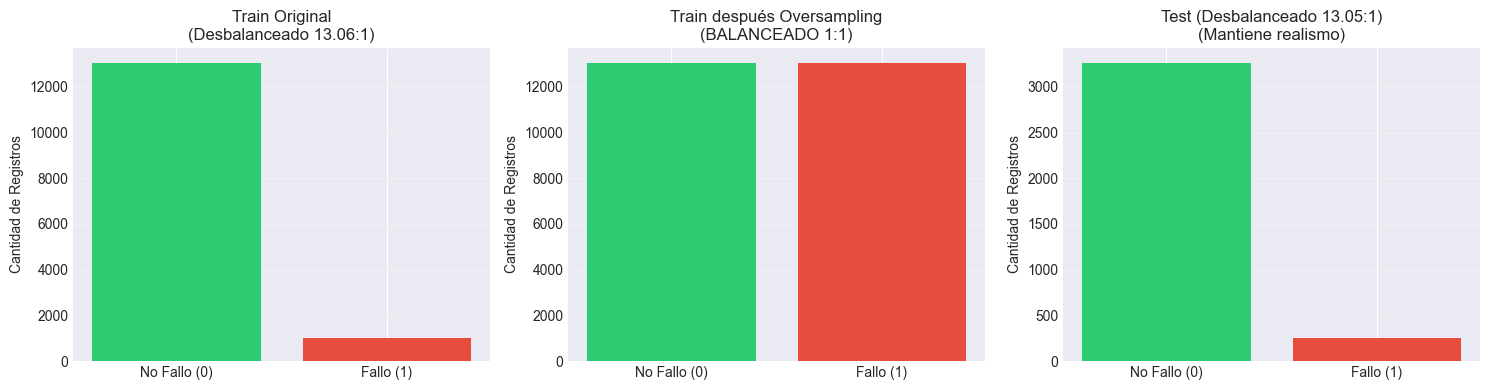


✅ Visualización guardada: 04_balanceo_oversampling.png


In [10]:
# Calcular Class Weights para modelos que lo soportan
print("⚖️  CLASS WEIGHTING Y OVERSAMPLING PARA DESBALANCE")
print("=" * 60)

# Calcular pesos de clases (automático)
class_weights = compute_class_weight('balanced', 
                                    classes=np.unique(y_train),
                                    y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

print(f"\n⚖️  Pesos de clases automáticos (para XGBoost/LightGBM):")
print(f"  • Clase 0 (No fallo): {class_weight_dict[0]:.4f}")
print(f"  • Clase 1 (Fallo):    {class_weight_dict[1]:.4f}")
print(f"  → Clase minoritaria tiene {class_weight_dict[1]/class_weight_dict[0]:.2f}x más peso")

# Aplicar RandomOverSampler para oversampling en TRAIN SET ÚNICAMENTE
# Nota: NUNCA se aplica oversampling en test set para mantener realismo
print(f"\n🎯 Aplicando RandomOverSampler (Oversampling) en TRAIN SET...")

try:
    ros = RandomOverSampler(random_state=42)
    X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)
    
    print(f"  ✅ RandomOverSampler aplicado exitosamente")
    print(f"\n📊 Distribución DESPUÉS de Oversampling en TRAIN:")
    oversampled_counts = pd.Series(y_train_balanced).value_counts()
    oversampled_pct = pd.Series(y_train_balanced).value_counts(normalize=True) * 100
    print(f"  • Clase 0: {oversampled_counts[0]:,} ({oversampled_pct[0]:.2f}%)")
    print(f"  • Clase 1: {oversampled_counts[1]:,} ({oversampled_pct[1]:.2f}%)")
    print(f"  • Ratio: {oversampled_counts[0]/oversampled_counts[1]:.2f}:1 (BALANCEADO)")
    
    usar_oversampler = True
except Exception as e:
    print(f"  ⚠️  RandomOverSampler falló: {str(e)}")
    print(f"  → Usando train set original sin oversampling")
    X_train_balanced = X_train.copy()
    y_train_balanced = y_train.copy()
    usar_oversampler = False

# TEST SET se mantiene DESBALANCEADO (para evaluación realista)
print(f"\n✅ TEST SET mantiene desbalance original:")
print(f"  • Preserva distribución real para evaluar modelos correctamente")

# Visualizar balanceo
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original Train
axes[0].bar(['No Fallo (0)', 'Fallo (1)'], train_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_ylabel('Cantidad de Registros')
axes[0].set_title(f'Train Original\n(Desbalanceado {train_counts[0]/train_counts[1]:.2f}:1)')
axes[0].grid(axis='y', alpha=0.3)

# After Oversampling
if usar_oversampler:
    axes[1].bar(['No Fallo (0)', 'Fallo (1)'], oversampled_counts.values, color=['#2ecc71', '#e74c3c'])
    axes[1].set_ylabel('Cantidad de Registros')
    axes[1].set_title(f'Train después Oversampling\n(BALANCEADO 1:1)')
    axes[1].grid(axis='y', alpha=0.3)
else:
    axes[1].bar(['No Fallo (0)', 'Fallo (1)'], train_counts.values, color=['#2ecc71', '#e74c3c'])
    axes[1].set_ylabel('Cantidad de Registros')
    axes[1].set_title(f'Train (sin Oversampling)')
    axes[1].grid(axis='y', alpha=0.3)

# Test (mantiene desbalance)
axes[2].bar(['No Fallo (0)', 'Fallo (1)'], test_counts.values, color=['#2ecc71', '#e74c3c'])
axes[2].set_ylabel('Cantidad de Registros')
axes[2].set_title(f'Test (Desbalanceado {test_counts[0]/test_counts[1]:.2f}:1)\n(Mantiene realismo)')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('04_balanceo_oversampling.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n✅ Visualización guardada: 04_balanceo_oversampling.png")

## Sección 10: Guardar Datos Preparados para Fase 2

In [11]:
# Guardar todos los datasets preparados
import pickle

print("💾 EXPORTANDO DATOS PREPARADOS PARA FASE 2")
print("=" * 60)

# Carpeta de salida
output_dir = Path('.')

# 1. Dataframe completo escalado (antes de split)
print(f"\n📁 Guardando datasets...")

# Guardar como CSV
df_modelo.to_csv(output_dir / 'datos_completos_procesados.csv', index=False)
print(f"  ✅ datos_completos_procesados.csv (con target)")

# 2. Training data (sin Oversampling - features originales)
train_data = pd.concat([X_train, y_train], axis=1)
train_data.to_csv(output_dir / 'X_train_normalizado.csv', index=False)
print(f"  ✅ X_train_normalizado.csv ({X_train.shape[0]:,} registros)")

# 3. Testing data
test_data = pd.concat([X_test, y_test], axis=1)
test_data.to_csv(output_dir / 'X_test_normalizado.csv', index=False)
print(f"  ✅ X_test_normalizado.csv ({X_test.shape[0]:,} registros)")

# 4. Training data BALANCEADO (con Oversampling)
train_balanced_data = pd.DataFrame(X_train_balanced, columns=X_train.columns)
train_balanced_data[target_col] = y_train_balanced
train_balanced_data.to_csv(output_dir / 'X_train_normalizado_Oversampled.csv', index=False)
print(f"  ✅ X_train_normalizado_Oversampled.csv ({X_train_balanced.shape[0]:,} registros balanceados)")

# 5. Guardar metadatos en JSON (convertir tipos numpy a Python)
metadata = {
    'dataset_info': {
        'total_registros': int(len(df_modelo)),
        'total_features': int(len(X_train.columns)),
        'feature_names': X_train.columns.tolist()
    },
    'class_distribution': {
        'class_0': int(class_counts[0]),
        'class_1': int(class_counts[1]),
        'ratio_desbalance': float(class_counts[0] / class_counts[1])
    },
    'train_test_split': {
        'train_size': int(len(X_train)),
        'test_size': int(len(X_test)),
        'train_class_0': int(train_counts[0]),
        'train_class_1': int(train_counts[1]),
        'test_class_0': int(test_counts[0]),
        'test_class_1': int(test_counts[1])
    },
    'oversampling_applied': bool(usar_oversampler),
    'class_weights': {
        'class_0': float(class_weight_dict[0]),
        'class_1': float(class_weight_dict[1])
    },
    'scaler_type': 'MinMaxScaler [0,1]',
    'encoding_strategy': {
        'tipo_trabajo': 'Target Encoding',
        'tipo_cliente': 'Label Encoding',
        'producto': 'Label Encoding',
        'fuente': 'Label Encoding',
        'boolean_columns': 'Kept as binary (0/1)'
    }
}

with open(output_dir / 'metadata_preprocesamiento.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"  ✅ metadata_preprocesamiento.json")

# 6. Guardar escalador y encoders (para aplicar a datos nuevos)
pickle.dump(scaler, open(output_dir / 'scaler_MinMaxScaler.pkl', 'wb'))
print(f"  ✅ scaler_MinMaxScaler.pkl")

pickle.dump(le_dict, open(output_dir / 'label_encoders.pkl', 'wb'))
print(f"  ✅ label_encoders.pkl")

pickle.dump(target_encoding, open(output_dir / 'target_encoding_tipo_trabajo.pkl', 'wb'))
print(f"  ✅ target_encoding_tipo_trabajo.pkl")

# 7. Crear resumen final
print(f"\n" + "=" * 60)
print(f"📊 RESUMEN FINAL DE PREPROCESSAMIENTO")
print(f"=" * 60)
print(f"\n✅ Total de archivos generados: 10")
print(f"\nPara FASE 2 (Modelado):")
print(f"  1. X_train_normalizado.csv ({int(len(X_train)):,} registros)")
print(f"  2. X_train_normalizado_Oversampled.csv ({int(X_train_balanced.shape[0]):,} registros balanceados)")
print(f"  3. X_test_normalizado.csv ({int(len(X_test)):,} registros)")
print(f"  4. metadata_preprocesamiento.json (configuración)")
print(f"\nDirectorio: {output_dir.absolute()}")

# Verificación final
print(f"\n✅ VERIFICACIÓN FINAL:")
print(f"  • NaN en X_train: {X_train.isnull().sum().sum()}")
print(f"  • NaN en X_test: {X_test.isnull().sum().sum()}")
print(f"  • Features: {len(X_train.columns)}")
print(f"  • Target variable: {target_col}")
print(f"  • Clase minoritaria en train: {int(train_counts[1]):,} registros")
print(f"  • Clase minoritaria en test: {int(test_counts[1]):,} registros")

💾 EXPORTANDO DATOS PREPARADOS PARA FASE 2

📁 Guardando datasets...
  ✅ datos_completos_procesados.csv (con target)
  ✅ X_train_normalizado.csv (14,046 registros)
  ✅ X_test_normalizado.csv (3,512 registros)
  ✅ X_train_normalizado_Oversampled.csv (26,094 registros balanceados)
  ✅ metadata_preprocesamiento.json
  ✅ scaler_MinMaxScaler.pkl
  ✅ label_encoders.pkl
  ✅ target_encoding_tipo_trabajo.pkl

📊 RESUMEN FINAL DE PREPROCESSAMIENTO

✅ Total de archivos generados: 10

Para FASE 2 (Modelado):
  1. X_train_normalizado.csv (14,046 registros)
  2. X_train_normalizado_Oversampled.csv (26,094 registros balanceados)
  3. X_test_normalizado.csv (3,512 registros)
  4. metadata_preprocesamiento.json (configuración)

Directorio: c:\Users\DELL\Documents\GitHub\material-redesneuronales\02-Preprocessamiento

✅ VERIFICACIÓN FINAL:
  • NaN en X_train: 0
  • NaN en X_test: 0
  • Features: 25
  • Target variable: Propenso_a_Fallar
  • Clase minoritaria en train: 999 registros
  • Clase minoritaria en 

## Sección 11: Diccionario de Datos y Lógica de Investigación

In [12]:
# DICCIONARIO DE DATOS CON LÓGICA DE INVESTIGACIÓN
print("📚 DICCIONARIO DE DATOS - NUEVAS VARIABLES ENGINEERED")
print("=" * 80)

data_dictionary = {
    "Pregunta Investigación": {
        "pregunta": "¿Cuáles son los factores predictivos que determinan la propensión al fallo en servicios de reparación?",
        "variable_target": "Propenso_a_Fallar (0: No fallo, 1: Fallo)",
        "objetivo": "Predecir servicios con alto riesgo de fallo para aplicar estrategias preventivas"
    },
    
    "Variables Originales Importancia": {
        "servicio_urgente": {
            "tipo": "Binaria",
            "rango": "[0, 1]",
            "logica": "Indicador si el servicio es urgente. Servicios urgentes pueden tener más presión temporal y riesgo de fallo"
        },
        "critico": {
            "tipo": "Binaria",
            "rango": "[0, 1]",
            "logica": "Indicador de criticidad del servicio. Servicios críticos pueden requerir mayor atención y menos probabilidad de error"
        },
        "tipo_trabajo_encoded": {
            "tipo": "Target Encoding",
            "rango": "[0, 1]",
            "logica": "Valor promedio de propensión a fallo por tipo de trabajo. Tipos concretos de trabajos tienen mayor predisposición al fallo"
        },
        "tipo_cliente_encoded": {
            "tipo": "Label Encoding",
            "rango": "[0, 2]",
            "logica": "Categoría de cliente codificada. Diferentes tipos de clientes pueden tener diferente complejidad de requerimientos"
        },
        "producto_encoded": {
            "tipo": "Label Encoding",
            "rango": "[0, n]",
            "logica": "Tipo de producto codificado. Algunos productos son más defectuosos o complejos de reparar"
        },
        "fuente_encoded": {
            "tipo": "Label Encoding",
            "rango": "[0, 1]",
            "logica": "Fuente de derivación del cliente. Diferentes fuentes pueden tener diferentes características de demanda"
        }
    },
    
    "Variables Engineered - Descripción": {
        "desc_longitud": {
            "tipo": "Numérica continua",
            "rango": "[0, max_chars]",
            "engineering": "Número de caracteres en la descripción",
            "logica": "Descripciones más largas pueden indicar problemas complejos con mayor riesgo de fallo. Descripciones cortas pueden ser omisiones"
        },
        "desc_num_palabras": {
            "tipo": "Numérica discreta",
            "rango": "[0, max_palabras]",
            "engineering": "Cantidad de palabras en la descripción",
            "logica": "Correlacionada con longitud. Más detalles en la descripción = problema más complejo = mayor riesgo"
        },
        "desc_contiene_instalación": {
            "tipo": "Binaria",
            "rango": "[0, 1]",
            "engineering": "1 si descripción contiene 'instalación'",
            "logica": "Tareas de instalación son complejas y propensas a errores de compatibilidad. Palabra clave discriminante"
        },
        "desc_contiene_problema": {
            "tipo": "Binaria",
            "rango": "[0, 1]",
            "engineering": "1 si descripción contiene 'problema'",
            "logica": "Presencia de 'problema' indica diagnóstico previo. Puede ser predictor agregado de complejidad"
        },
        "desc_contiene_componente": {
            "tipo": "Binaria",
            "rango": "[0, 1]",
            "engineering": "1 si descripción contiene 'componente'",
            "logica": "Reparaciones que mencionan componentes específicos tienen mayor complejidad técnica"
        },
        "desc_contiene_conexión": {
            "tipo": "Binaria",
            "rango": "[0, 1]",
            "engineering": "1 si descripción contiene 'conexión'",
            "logica": "Problemas de conexión son diagnósticos ambiguos, mayor riesgo de fallo si la causa raíz no se identifica"
        },
        "desc_contiene_falla": {
            "tipo": "Binaria",
            "rango": "[0, 1]",
            "engineering": "1 si descripción contiene 'falla'",
            "logica": "Palabra clave fuertemente discriminante que indica fallo previo y riesgo de fallo"
        },
        "desc_contiene_arranque": {
            "tipo": "Binaria",
            "rango": "[0, 1]",
            "engineering": "1 si descripción contiene 'arranque'",
            "logica": "Problemas de arranque son síntomas superficiales, pueden ocultar problemas más profundos"
        },
        "desc_contiene_error": {
            "tipo": "Binaria",
            "rango": "[0, 1]",
            "engineering": "1 si descripción contiene 'error'",
            "logica": "Presencia de 'error' indica complicación potencial o resultado de diagnóstico fallido"
        },
        "desc_contiene_funciona": {
            "tipo": "Binaria",
            "rango": "[0, 1]",
            "engineering": "1 si descripción contiene 'funciona'",
            "logica": "Puede indicar servicios de ajuste/optimización vs reparación de fallo. Generalmente menor riesgo"
        },
        "desc_contiene_revisar": {
            "tipo": "Binaria",
            "rango": "[0, 1]",
            "engineering": "1 si descripción contiene 'revisar'",
            "logica": "Indica diagnóstico preliminar o falta de claridad. Mayor riesgo por incertidumbre"
        },
        "desc_contiene_piezas": {
            "tipo": "Binaria",
            "rango": "[0, 1]",
            "engineering": "1 si descripción contiene 'piezas'",
            "logica": "Necesidad de piezas de reemplazo indica mayor complejidad y dependencia de disponibilidad"
        },
        "desc_es_largo": {
            "tipo": "Binaria",
            "rango": "[0, 1]",
            "engineering": "1 si desc_longitud > mediana del dataset",
            "logica": "Binaria derivada. Descripciones largas (> mediana) señalan problemas más complejos"
        },
        "desc_muchas_palabras": {
            "tipo": "Binaria",
            "rango": "[0, 1]",
            "engineering": "1 si desc_num_palabras > mediana del dataset",
            "logica": "Binaria derivada. Correlacionada con desc_es_largo. Redundancia controlada para capturar complejidad"
        }
    },
    
    "Variables Engineered - Interacciones": {
        "urgente_x_tipo_trabajo": {
            "tipo": "Numérica continua",
            "rango": "[0, max_encoded]",
            "engineering": "servicio_urgente * tipo_trabajo_encoded",
            "logica": "Captura la INTERACCIÓN entre urgencia del servicio y tipo de trabajo. Servicios urgentes en trabajos de alto riesgo multiplican la propensión a fallo"
        },
        "urgente_x_cliente": {
            "tipo": "Numérica continua",
            "rango": "[0, max_encoded]",
            "engineering": "servicio_urgente * tipo_cliente_encoded",
            "logica": "Captura INTERACCIÓN entre urgencia y tipo de cliente. Clientes exigentes en servicios urgentes = mayor estrés y errores"
        },
        "critico_x_tipo_trabajo": {
            "tipo": "Numérica continua",
            "rango": "[0, max_encoded]",
            "engineering": "critico * tipo_trabajo_encoded",
            "logica": "Captura INTERACCIÓN entre criticidad y tipo de trabajo. Trabajos críticos en categorías de alto riesgo multiplican propensión"
        },
        "urgente_desc_largo": {
            "tipo": "Binaria",
            "rango": "[0, 1]",
            "engineering": "servicio_urgente * desc_es_largo",
            "logica": "Captura INTERACCIÓN entre urgencia temporal y complejidad técnica. Servicios urgentes complejos muy propensos a fallo"
        }
    },
    
    "Variables Engineered - Composición": {
        "indice_prioridad": {
            "tipo": "Numérica discreta",
            "rango": "[0, 2]",
            "engineering": "servicio_urgente + critico",
            "logica": "Índice compuesto de prioridad del servicio. Suma 0=Normal, 1=Urgente O Crítico, 2=Ambos. Mayor índice = Mayor presión = Mayor riesgo"
        }
    },
    
    "Normalización Aplicada": {
        "metodo": "MinMaxScaler",
        "rango_salida": "[0, 1]",
        "formula": "(X - X_min) / (X_max - X_min)",
        "ventaja": "Preserva estructura de datos, interpretable, ideal para redes neuronales, mantiene ceros",
        "aplicacion": "Se aplica DESPUÉS de feature engineering para asegurar coherencia"
    },
    
    "Balanceo Aplicado": {
        "metodo": "RandomOverSampler",
        "estrategia": "Replicar aleatoriamente muestras de la clase minoritaria (Fallo=1)",
        "aplicacion": "Solo en TRAIN SET. TEST SET mantiene desbalance real para evaluación honesta",
        "resultado_train": f"{int(oversampled_counts[0]):,} muestras no-fallo, {int(oversampled_counts[1]):,} muestras fallo (1:1)",
        "resultado_test": f"{int(test_counts[0]):,} no-fallo, {int(test_counts[1]):,} fallo (original {test_counts[0]/test_counts[1]:.2f}:1)"
    }
}

# Mostrar diccionario formateado
print("\n🔍 PREGUNTA DE INVESTIGACIÓN:")
print(f"  {data_dictionary['Pregunta Investigación']['pregunta']}")
print(f"\n🎯 Variable Target: {data_dictionary['Pregunta Investigación']['variable_target']}")
print(f"\n📌 Objetivo: {data_dictionary['Pregunta Investigación']['objetivo']}")

print("\n" + "=" * 80)
print("\n📋 VARIABLES ENGINEERED Y SU LÓGICA:")
print(f"\n{'Variable':<35} {'Tipo':<20} {'Lógica Investigación':<50}")
print("-" * 105)

# Variables de descripción
for var, info in data_dictionary['Variables Engineered - Descripción'].items():
    logica_short = info['logica'][:47] + "..." if len(info['logica']) > 47 else info['logica']
    print(f"{var:<35} {info['tipo']:<20} {logica_short:<50}")

# Variables de interacción
print("\n📊 VARIABLES DE INTERACCIÓN (Capturan efectos multiplicativos):")
print("-" * 105)
for var, info in data_dictionary['Variables Engineered - Interacciones'].items():
    logica_short = info['logica'][:47] + "..." if len(info['logica']) > 47 else info['logica']
    print(f"{var:<35} {info['tipo']:<20} {logica_short:<50}")

# Variables compuestas
print("\n🔗 VARIABLES COMPUESTAS (Índices agregados):")
print("-" * 105)
for var, info in data_dictionary['Variables Engineered - Composición'].items():
    logica_short = info['logica'][:47] + "..." if len(info['logica']) > 47 else info['logica']
    print(f"{var:<35} {info['tipo']:<20} {logica_short:<50}")

print("\n" + "=" * 80)
print("\n✅ METODOLOGÍA APLICADA:")
print(f"\n🔄 Normalización: {data_dictionary['Normalización Aplicada']['metodo']}")
print(f"   Rango: {data_dictionary['Normalización Aplicada']['rango_salida']}")
print(f"   Ventaja: {data_dictionary['Normalización Aplicada']['ventaja']}")

print(f"\n⚖️  Balanceo: {data_dictionary['Balanceo Aplicado']['metodo']}")
print(f"   Aplicación: {data_dictionary['Balanceo Aplicado']['aplicacion']}")
print(f"   Train resultado: {data_dictionary['Balanceo Aplicado']['resultado_train']}")
print(f"   Test resultado: {data_dictionary['Balanceo Aplicado']['resultado_test']}")

# Guardar diccionario de datos en JSON
with open(output_dir / 'diccionario_datos_variables_engineered.json', 'w', encoding='utf-8') as f:
    json.dump(data_dictionary, f, indent=2, ensure_ascii=False)
print(f"\n✅ Diccionario guardado: diccionario_datos_variables_engineered.json")

📚 DICCIONARIO DE DATOS - NUEVAS VARIABLES ENGINEERED

🔍 PREGUNTA DE INVESTIGACIÓN:
  ¿Cuáles son los factores predictivos que determinan la propensión al fallo en servicios de reparación?

🎯 Variable Target: Propenso_a_Fallar (0: No fallo, 1: Fallo)

📌 Objetivo: Predecir servicios con alto riesgo de fallo para aplicar estrategias preventivas


📋 VARIABLES ENGINEERED Y SU LÓGICA:

Variable                            Tipo                 Lógica Investigación                              
---------------------------------------------------------------------------------------------------------
desc_longitud                       Numérica continua    Descripciones más largas pueden indicar problem...
desc_num_palabras                   Numérica discreta    Correlacionada con longitud. Más detalles en la...
desc_contiene_instalación           Binaria              Tareas de instalación son complejas y propensas...
desc_contiene_problema              Binaria              Presencia de 'problema